# Les arbres de Paris 

## Une analyse de la population d'arbres dans Paris 

Pour ce projet nous avons décidé de travailler sur les arbres dans Paris. Pour cela nous nous appuyons sur la base de données établie par la mairie de Paris recensant les arbres: leur emplacement, taille, circonférence ou encore espèce. Nous utilisons aussi la base de données sur les IRIS en france afin d'établir des liens géographique par iris. 

### Nettoyage de la base de données

Nous commencons par charger et nettoyer les bases de données 

On remarque que notre table contient trop de colonnes inutiles : 

- IDBASE : id de la ligne inutile
- cleabs : Identifiant technique IGN
- IDEMPLACEMENT, COMPLEMENT ADRESSE, LIEU / ADRESSE : indications géographique inutiles comme on possède la localisation. 
- iris : déjà contenu dans code_iris, qui est un indentifiant complet et unique. 
- geo_point_2d, lat et lon : redondant avec geometry
- 'nom_commune : variable doublée (arrondissement)
- index_right : rajoutée avec la jointure
- TYPE EMPLACEMENT : modalité Arbre partout. 

In [1]:
import sys
sys.path.append('../src')
import utils
import pandas as pd
import s3fs
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D


In [2]:
arbres = pd.read_csv("https://www.data.gouv.fr/api/1/datasets/r/60433484-f30e-44ef-a362-e5553a9b7a42", sep = ";")
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})

MY_BUCKET = "raphcrre"
PATH_IRIS = f"{MY_BUCKET}/diffusion/projet_arbres/iris.gpkg"

with fs.open(PATH_IRIS, 'rb') as f:
    iris_france = gpd.read_file(f)

iris = iris_france[iris_france['code_insee'].astype(str).str.startswith('75')].copy()
df_arbres = utils.jointure_arbres_iris(arbres, iris)
df_arbres

df_arbres = utils.suppression_colonnes(df_arbres)


df_arbres = utils.nettoyer_valeurs_aberrantes(df_arbres)

print("-" * 30)
print(f"Statistiques après nettoyage :")
print(f"Hauteur moyenne : {df_arbres['hauteur_m'].mean():.2f} m")
print(f"Circonférence moyenne : {df_arbres['circonference_cm'].mean():.2f} cm")
print("-" * 30)
df_arbres


/opt/python/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsimem/pyogrio_4899a41c7f844e068d00e91a214bc516 has GPKG application_id, but non conformant file extension
  return ogr_read(


Nettoyage terminé : 22771 lignes supprimées (Manquants + Aberrations).
Il reste 194981 arbres dans la base.
------------------------------
Statistiques après nettoyage :
Hauteur moyenne : 10.02 m
Circonférence moyenne : 89.88 cm
------------------------------


,domanialite,arrondissement,libelle_francais,genre,espece,variete_oucultivar,circonference_cm,hauteur_m,stade_de_developpement,remarquable,geometry,code_insee,code_iris,nom_iris,type_iris
0,Alignement,PARIS 19E ARRDT,Platane,Platanus,x hispanica,NaN,85,12,Adulte,NON,POINT (654547.64 6866707.873),75119,751197413,Pont de Flandre 13,A
1,Jardin,PARIS 13E ARRDT,Frêne,Fraxinus,excelsior,NaN,215,18,Mature,NON,POINT (652930.348 6858862.165),75113,751135028,Gare 28,H
2,Jardin,PARIS 15E ARRDT,Sorbier,Sorbus,latifolia,''Henk Vink'',25,6,Jeune (arbre),NON,POINT (647930.563 6859917.829),75115,751155711,Saint-Lambert 11,H
3,Alignement,PARIS 10E ARRDT,Platane,Platanus,x hispanica,NaN,156,20,Adulte,NON,POINT (652924.333 6864159.908),75110,751103910,Porte Saint-Martin 10,H
4,Jardin,PARIS 10E ARRDT,Charme,Carpinus,betulus,NaN,25,4,Jeune (arbre),NON,POINT (653210.669 6864048.707),75110,751104008,Hôpital Saint-Louis 8,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217747,Alignement,PARIS 13E ARRDT,Orme,Ulmus,minor,NaN,135,20,Adulte,NON,POINT (652845.655 6858565.356),75113,751135105,Maison Blanche 5,H
217748,Jardin,PARIS 8E ARRDT,Erable,Acer,platanoides,''Schwedleri'',171,15,Adulte,NON,POINT (649356 6864555.333),75108,751083203,Europe 3,H
217749,Alignement,BOIS DE VINCENNES,Noyer,Juglans,nigra,NaN,115,15,Adulte,NON,POINT (658666.918 6858824.355),75112,751124677,Bois de Vincennes 2,D
217750,Jardin,PARIS 15E ARRDT,Magnolia,Magnolia,stellata,NaN,45,7,Adulte,NON,POINT (647173.657 6861139.144),75115,751156014,Javel 14,H


## Visualisation

### TOP 10 des essences (types d'arbres à Paris)
Nous voulons maintenant faire quelques statistiques descrptives sur les arbres à Paris. 
D'abord nous nous demandons quelles sont les epsèces d'arbres les plus fréquentes. 

/tmp/ipykernel_153591/844377904.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


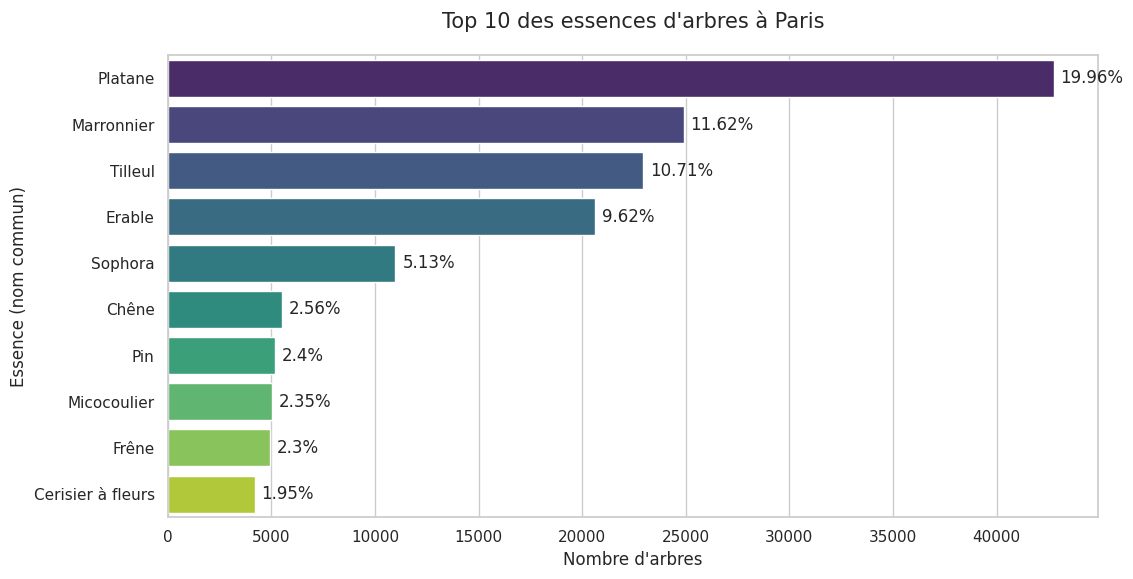

In [3]:
df_top = utils.get_top_species(arbres, column_name = "LIBELLE FRANCAIS")


plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_top, 
    x='Nombre', 
    y='Espece', 
    palette='viridis'
)

plt.title('Top 10 des essences d\'arbres à Paris', fontsize=15, pad=20)
plt.xlabel('Nombre d\'arbres')
plt.ylabel('Essence (nom commun)')

for i, p in enumerate(ax.patches):
    percentage = f"{df_top['Pourcentage'].iloc[i]}%"
    ax.annotate(percentage, (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.show()

#### Répartition du stade de développement 

Puis nous nous interrogeons sur l'ancienneté des arbres. 

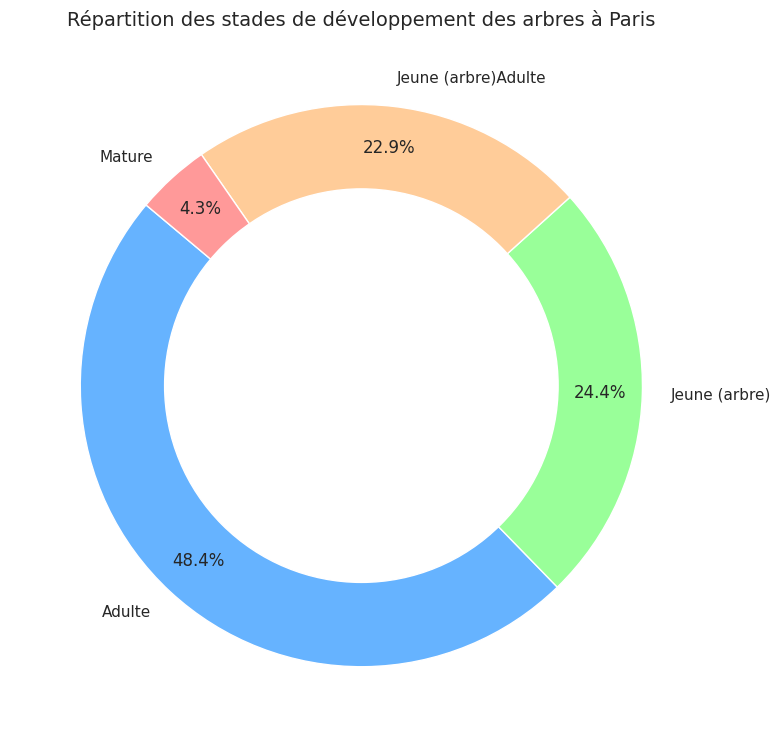

In [4]:
df_stade = utils.get_development_stats(arbres)

plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'] # Couleurs douces

plt.pie(
    df_stade['Proportion'], 
    labels=df_stade['Stade'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Répartition des stades de développement des arbres à Paris", fontsize=14)
plt.tight_layout()
plt.show()

### Modélisation des stades de développement 

On peut ensuite modéliser ces stades moyens de développement par Iris ou par arrondissement de façon intéractvie pour se rendre davatage compte de la typologie parisienne des arbres. 

In [5]:
print("\n--- INFOS GÉNÉRALES ---")

gdf_iris_stats = utils.preparer_geodata_stade(iris, df_arbres, niveau='iris')
gdf_iris_stats[['code_iris', 'nom_iris', 'stade_dominant', 'pct_Jeune', 'pct_Adulte', 'pct_Vieux']].head()

mapping_arrdt = {
    '75101': 'PARIS 1ER ARRDT',
    '75102': 'PARIS 2E ARRDT',
    '75103': 'PARIS 3E ARRDT',
    '75104': 'PARIS 4E ARRDT',
    '75105': 'PARIS 5E ARRDT',
    '75106': 'PARIS 6E ARRDT',
    '75107': 'PARIS 7E ARRDT',
    '75108': 'PARIS 8E ARRDT',
    '75109': 'PARIS 9E ARRDT',
    '75110': 'PARIS 10E ARRDT',
    '75111': 'PARIS 11E ARRDT',
    '75112': 'PARIS 12E ARRDT',
    '75113': 'PARIS 13E ARRDT',
    '75114': 'PARIS 14E ARRDT',
    '75115': 'PARIS 15E ARRDT',
    '75116': 'PARIS 16E ARRDT',
    '75117': 'PARIS 17E ARRDT',
    '75118': 'PARIS 18E ARRDT',
    '75119': 'PARIS 19E ARRDT',
    '75120': 'PARIS 20E ARRDT',
}

iris_avec_arrdt = iris.copy()
iris_avec_arrdt['arrondissement'] = iris_avec_arrdt['code_insee'].map(mapping_arrdt)

iris_avec_arrdt = iris_avec_arrdt[iris_avec_arrdt['arrondissement'].notna()]

gdf_arrdt = iris_avec_arrdt.dissolve(by='arrondissement').reset_index()[['arrondissement', 'geometry']]

gdf_arrdt_stats = utils.preparer_geodata_stade(gdf_arrdt, df_arbres, niveau='arrondissement')

print(gdf_arrdt_stats[['arrondissement', 'stade_dominant', 'total', 'pct_Jeune', 'pct_Adulte', 'pct_Vieux']])

carte = utils.carte_stade_paris(
    gdf_iris_stats=gdf_iris_stats,
    gdf_arrdt_stats=gdf_arrdt_stats,
    titre="Stade dominant des arbres à Paris"
)
carte


--- INFOS GÉNÉRALES ---
     arrondissement stade_dominant  total  pct_Jeune  pct_Adulte  pct_Vieux
0   PARIS 10E ARRDT         Adulte   3429       23.2        68.5        8.3
1   PARIS 11E ARRDT         Adulte   5369       24.7        75.0        0.3
2   PARIS 12E ARRDT         Adulte  11122       17.1        81.9        1.0
3   PARIS 13E ARRDT         Adulte  15103       30.6        65.3        4.1
4   PARIS 14E ARRDT         Adulte  11656       42.3        54.3        3.3
5   PARIS 15E ARRDT         Adulte  11873       13.2        85.3        1.5
6   PARIS 16E ARRDT         Adulte  15406       20.7        71.6        7.7
7   PARIS 17E ARRDT         Adulte  11759       36.8        59.6        3.6
8   PARIS 18E ARRDT         Adulte  10438       28.6        65.4        5.9
9   PARIS 19E ARRDT         Adulte  11742       19.9        74.9        5.2
10  PARIS 1ER ARRDT         Adulte   1641       21.4        78.0        0.6
11  PARIS 20E ARRDT         Adulte  15472       20.8        77.

Les 20 IRIS vides se répartissent en 3 catégories bien distinctes :

Type A (7 IRIS) → zones d'activités commerciales/tertiaires (Palais Royal, Madeleine, Chaussée d'Antin...). Pas d'arbres municipaux recensés, ce qui est logique.
Type D (1 IRIS) → Tuileries, c'est une zone de grande emprise (le jardin des Tuileries). Paradoxalement sans données, probablement parce que les arbres des jardins historiques gérés par l'État ne sont pas dans le dataset municipal de Paris.
Type H (12 IRIS) → zones à forte emprise d'équipements publics (hôpitaux, casernes, universités...). Même raison : les arbres de ces emprises ne sont pas gérés par la ville de Paris donc absents du dataset.

C'est une limite connue du dataset arbres.data.gouv.fr qui ne recense que les arbres gérés par la Direction des Espaces Verts de la Ville de Paris, et exclut donc les arbres appartenant à l'État, aux hôpitaux, aux universités, etc. 

### Modélisation de la densité d'arbres à Paris

On veut ensuite représenter la densité de population d'arbres dans Paris. Selon les IRIS ou les arrondissement et toujours de manière intéractive. On ajoute aussi un figuré ponctuel avec les arbres remarquables de Paris.

In [6]:
gdf_iris_densite = utils.calculer_densite_par_zone(df_arbres, iris, groupby_col='code_iris')

gdf_arrdt_densite = utils.calculer_densite_par_zone(df_arbres, gdf_arrdt, groupby_col='arrondissement')

gdf_remarquables = utils.extraire_arbres_remarquables(df_arbres, top_n_hauteur=50, top_n_circonf=50)
print(f"{len(gdf_remarquables)} arbres remarquables extraits")
print(gdf_remarquables[['libelle_francais', 'hauteur_m', 'circonference_cm', 'motif_remarquable']].head())

carte_densite = utils.carte_densite_paris(
    gdf_iris_densite=gdf_iris_densite,
    gdf_arrdt_densite=gdf_arrdt_densite,
    gdf_remarquables=gdf_remarquables,
    titre="Densité d'arbres à Paris"
)
carte_densite


244 arbres remarquables extraits
     libelle_francais  hauteur_m  circonference_cm  \
183               Pin         20               250   
259        Pterocarya         30               435   
1985         Peuplier         35               445   
4983          Platane         35               420   
5614          Platane         30               480   

                    motif_remarquable  
183                       Remarquable  
259                       Remarquable  
1985  Top hauteur · Top circonférence  
4983        Remarquable · Top hauteur  
5614                Top circonférence  


## Clustering 

Nous utilisons maintenant une méthode de clustering pour établir des profils types d'iris en fonction de leur population d'arbres. 

Préaration de la base de données pour le clustering + test du coude pour trouver nombre de cluster idéal 

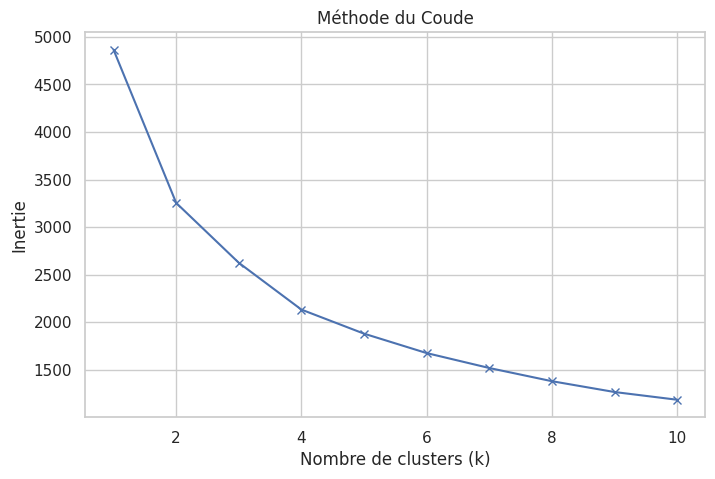

In [7]:
donnees_clustering = utils.preparer_clustring(df_arbres)

utils.choix_k_coude(donnees_clustering)

iris_clustered = utils.applique_clustering(donnees_clustering, n_clusters=4)


D'après le théorème du coude, il semble plus optimal de choisir un k = 4
On peut donc faire notre clustering avec 4 clusters

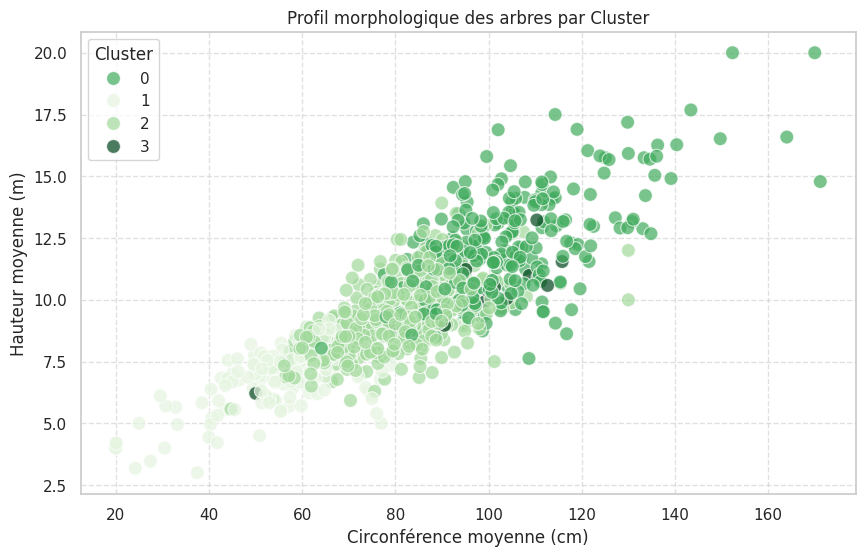

         circ_moyenne   circ_std  haut_moyenne   haut_max    nb_arbres
cluster                                                               
0          102.716574  60.238445     12.073382  25.090000   201.133333
1           57.605264  29.485372      7.089468  13.605096    69.312102
2           79.843744  45.583713      9.367737  20.402390   139.567729
3           96.306507  63.280342     10.223054  30.142857  2831.642857


In [8]:
custom_palette = {
    2: "#a1d99b",  
    0: "#41ab5d",  
    1: "#e5f5e0",  
    3: "#00441b"   
}

utils.plot_morpho(iris_clustered, custom_palette)

stats = utils.moyennes_cluster(iris_clustered)
print(stats)


En affichant les moyennes de hauteurs, circonferences et nombre par cluster, on voit bien que 4 groupes bien distincts se créeent: 

1.	Cluster 3 (Le plus foncé) : Les "Forêts Urbaines". Moyenne de 2832 arbres par Iris et une hauteur max record de 30m. C'est le cluster des bois.
2.	Cluster 0 (Vert soutenu) : Les "Quartiers Arborés et Anciens". Ils ont le nombre d'arbres le plus élevé après les bois (201) et la circonférence moyenne la plus forte (102 cm).
3.	Cluster 2 (Vert moyen) : Le "Standard Parisien". Un profil équilibré, environ 140 arbres par IRIS avec une morphologie moyenne.
4.	Cluster 1 (Vert très clair) : Les "Zones Jeunes ou Minérales". Plus petites circonférences (57 cm) et moins d'arbres.

On peut maintenant représenter nos clusters sur une carte: 

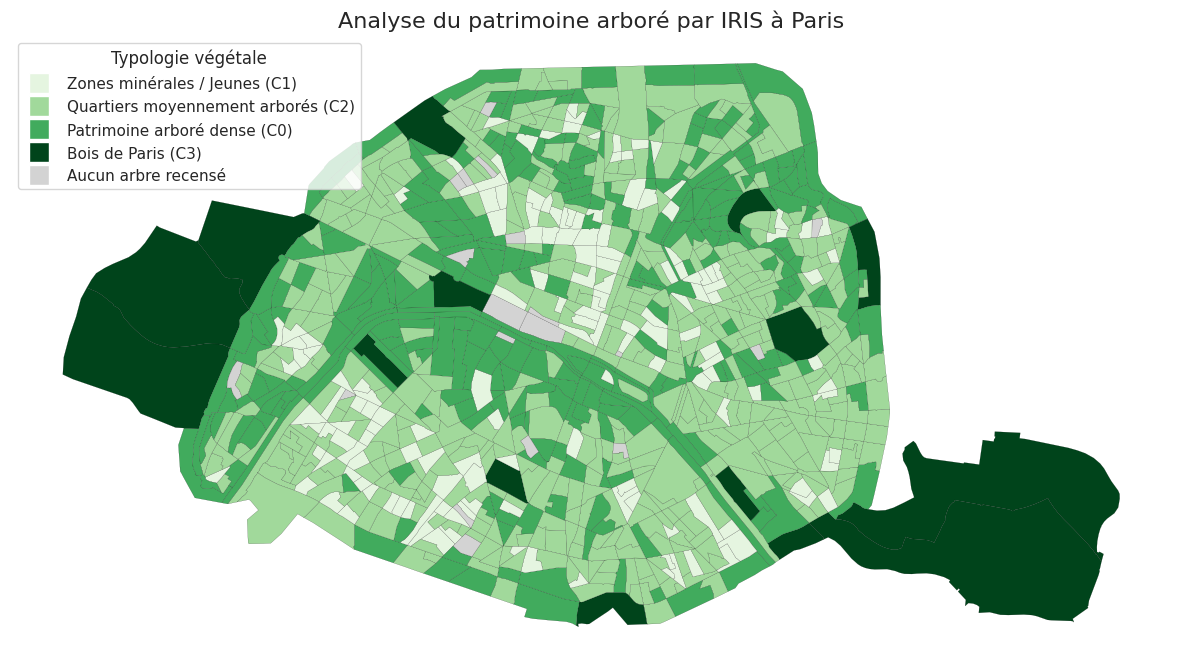

,cleabs,code_insee,nom_commune,iris,code_iris,nom_iris,type_iris,geometry,cluster,cluster_str
0,IRIS____0000000751010102,75101,Paris 1er Arrondissement,0102,751010102,Saint-Germain l'Auxerrois 2,A,"MULTIPOLYGON (((652048.7 6861993.1, 652000.9 6...",0.0,0.0
1,IRIS____0000000751010103,75101,Paris 1er Arrondissement,0103,751010103,Saint-Germain l'Auxerrois 3,A,"MULTIPOLYGON (((651639.9 6862521.6, 651869 686...",2.0,2.0
2,IRIS____0000000751010104,75101,Paris 1er Arrondissement,0104,751010104,Saint-Germain l'Auxerrois 4,A,"MULTIPOLYGON (((651514.6 6862585.4, 651639.9 6...",Sans arbres,Sans arbres
3,IRIS____0000000751010205,75101,Paris 1er Arrondissement,0205,751010205,Les Halles 5,A,"MULTIPOLYGON (((652198.8 6862680.2, 652146.4 6...",1.0,1.0
4,IRIS____0000000751010206,75101,Paris 1er Arrondissement,0206,751010206,Les Halles 6,A,"MULTIPOLYGON (((651670.6 6863058.7, 651808.1 6...",2.0,2.0
...,...,...,...,...,...,...,...,...,...,...
987,IRIS____0000000751208022,75120,Paris 20e Arrondissement,8022,751208022,Charonne 22,H,"MULTIPOLYGON (((656411.5 6862589, 656445.6 686...",0.0,0.0
988,IRIS____0000000751208023,75120,Paris 20e Arrondissement,8023,751208023,Charonne 23,H,"MULTIPOLYGON (((656511.6 6862331, 656434.9 686...",2.0,2.0
989,IRIS____0000000751208024,75120,Paris 20e Arrondissement,8024,751208024,Charonne 24,H,"MULTIPOLYGON (((656034.7 6861937.3, 655928.7 6...",2.0,2.0
990,IRIS____0000000751208025,75120,Paris 20e Arrondissement,8025,751208025,Charonne 25,H,"MULTIPOLYGON (((655877.3 6861839.9, 655832.6 6...",1.0,1.0


In [9]:
couleurs_vertes = {
    "1.0": "#e5f5e0",       
    "2.0": "#a1d99b",       
    "0.0": "#41ab5d",       
    "3.0": "#00441b",       
    "Sans arbres": "#D3D3D3" 
}


map_df = iris.merge(iris_clustered[['code_iris', 'cluster']], on='code_iris', how='left')

map_df['cluster'] = map_df['cluster'].fillna("Sans arbres")

utils.plot_map_cluster(map_df, couleurs_vertes)
map_df
